## 1. Imports & Konfiguration

In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import GroupShuffleSplit

torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Gerät:', DEVICE)

# ── Pfade ─────────────────────────────────────────────────────────────────────
CSV_PATH   = '../input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
BBOX_PATH  = '../input/datasets/organizations/nih-chest-xrays/data/BBox_List_2017.csv'
IMAGE_GLOB = '../input/datasets/organizations/nih-chest-xrays/data/images_*/images/*.png'
PTH_PATH   = '/kaggle/input/models/alexandernigg/resnet18/pytorch/default/1/resnet18_xray_final.pth'

IMG_SIZE      = 224
BATCH_SIZE    = 16
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
CLASS_NAMES   = {0: 'No Finding', 1: 'Infiltration'}

print('CSV    vorhanden:', os.path.exists(CSV_PATH))
print('BBox   vorhanden:', os.path.exists(BBOX_PATH))
print('Modell vorhanden:', os.path.exists(PTH_PATH))

Gerät: cuda
CSV    vorhanden: True
BBox   vorhanden: True
Modell vorhanden: True


## 2. Load Dataset 

In [2]:
all_xray_df = pd.read_csv(CSV_PATH)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].astype(str).str.rstrip('Y').astype(int)

# Bildpfade zuordnen
all_image_paths = {os.path.basename(x): x for x in glob(IMAGE_GLOB)}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

# Binäres Label: 0 = No Finding, 1 = Infiltration
def assign_binary_label(finding: str):
    if finding == 'No Finding':
        return 0
    elif 'Infiltration' in finding:
        return 1
    return None

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)

# Zeilen ohne gültigen Pfad oder Label entfernen
all_xray_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
all_xray_df['binary_label'] = all_xray_df['binary_label'].astype(int)

counts = all_xray_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Infiltration'})
print('Klassenverteilung:')
print(counts)
print(f'\nGesamt: {len(all_xray_df)} Bilder')

Klassenverteilung:
binary_label
No Finding      60361
Infiltration    19894
Name: count, dtype: int64

Gesamt: 80255 Bilder


## 3. Load Bounding Boxes 

In [3]:
bbox_df = pd.read_csv(BBOX_PATH)

# Spalten umbenennen für einfachere Handhabung
bbox_df = bbox_df.rename(columns={
    'Bbox [x': 'x',
    'y':       'y',
    'w':       'w',
    'h]':      'h'
})[['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]

# Nur Infiltrate-BBoxen behalten
infiltrate_bbox = bbox_df[bbox_df['Finding Label'] == 'Infiltrate'].copy()

# Koordinaten von 1024x1024 auf 224x224 skalieren
scale = IMG_SIZE / 1024.0
for col in ['x', 'y', 'w', 'h']:
    infiltrate_bbox[col] = infiltrate_bbox[col] * scale

# Lookup: Image Index -> BBox (erste Box pro Bild)
bbox_lookup = infiltrate_bbox.groupby('Image Index').first()[['x', 'y', 'w', 'h']].to_dict('index')

print(f'Infiltrate BBoxes verfügbar: {len(infiltrate_bbox)}')
print(f'Eindeutige Bilder mit BBox:  {len(bbox_lookup)}')
print('\nBeispiel-BBox (skaliert auf 224px):')
print(infiltrate_bbox.head(3).to_string(index=False))

Infiltrate BBoxes verfügbar: 123
Eindeutige Bilder mit BBox:  123

Beispiel-BBox (skaliert auf 224px):
     Image Index Finding Label          x          y          w         h
00020259_002.png    Infiltrate 133.777778 117.048298  54.506667 43.555556
00008814_010.png    Infiltrate  44.924444  85.937187 140.871111 18.915556
00012021_081.png    Infiltrate 143.484444  96.888298  42.062222 43.306667


### Train / Test

In [4]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(splitter.split(all_xray_df, groups=all_xray_df['Patient ID']))

train_df = all_xray_df.iloc[train_idx].reset_index(drop=True)
temp_df  = all_xray_df.iloc[temp_idx].reset_index(drop=True)

splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(splitter2.split(temp_df, groups=temp_df['Patient ID']))

valid_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)

# Sicherheitscheck
assert len(set(train_df['Patient ID']) & set(valid_df['Patient ID'])) == 0
assert len(set(train_df['Patient ID']) & set(test_df['Patient ID']))  == 0
print('Kein Patientenüberlapp — Split sauber ✓')
print(f'Train: {len(train_df):6d}  |  Val: {len(valid_df):6d}  |  Test: {len(test_df):6d}')

Kein Patientenüberlapp — Split sauber ✓
Train:  56768  |  Val:  11926  |  Test:  11561


### DataLoader

In [5]:
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class XRayDataset(Dataset):
    """Lädt X-Ray Bilder mit optionalem Bildpfad im Rückgabewert."""

    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = torch.tensor(row['binary_label'], dtype=torch.float32)
        fname = row['Image Index']
        if self.transform:
            image = self.transform(image)
        return image, label, fname   # fname für BBox-Lookup


test_dataset = XRayDataset(test_df, transform=eval_transforms)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=False
)

print(f'Test-Batches: {len(test_loader)}')

Test-Batches: 723


### Load Model

In [6]:
def build_resnet18():
    """Exakt dieselbe Architektur wie beim Training."""
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, 1),
        nn.Sigmoid()
    )
    return model


checkpoint = torch.load(PTH_PATH, map_location=DEVICE, weights_only=False)
model      = build_resnet18().to(DEVICE)
state      = checkpoint.get('model_state_dict', checkpoint)
model.load_state_dict(state)
model.eval()

print('Modell erfolgreich geladen ✓')
print(f'Test-AUC aus Training: {checkpoint.get("test_auc", "N/A")}')

# Schnelltest
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    print('Output-Shape:', model(dummy).shape)  # [2, 1]

Modell erfolgreich geladen ✓
Test-AUC aus Training: 0.7619
Output-Shape: torch.Size([2, 1])


In [7]:
# ── 7.1 Feature Maps extrahieren ─────────────────────────────────────────────

def extract_feature_maps(model, images):
    """
    Feature Maps aus layer4 (vor dem FC-Kopf).
    Rückgabe: (batch, 512, 7, 7)
    """
    feat = []
    hook = model.layer4.register_forward_hook(lambda m, i, o: feat.append(o))
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    return feat[0]


# ── 7.2 Entscheidungsgrenze berechnen ────────────────────────────────────────

def get_boundary_params(model):
    """
    Effektive Grenzrichtung Wm im 512-dimensionalen Feature-Space.
    Verkettet fc[1] (512→256) und fc[4] (256→1).
    """
    W1 = model.fc[1].weight.data   # (256, 512)
    b1 = model.fc[1].bias.data     # (256,)
    W2 = model.fc[4].weight.data   # (1, 256)
    b2 = model.fc[4].bias.data     # (1,)

    Wm = (W2 @ W1).squeeze(0)      # (512,)
    bm = (W2 @ b1 + b2).squeeze(0) # scalar
    return Wm, bm


# ── 7.3 Positionsfunktion (Paper Eq. 1) ──────────────────────────────────────

def position_function(zs_batch, Wm, bm, k):
    """
    P(zs, Wm, bm, k) = zs - 2k * (Wm^T zs + bm) * Ŵm
    Eingabe: zs_batch (B, 512, 7, 7), Wm (512,), bm scalar, k float
    Ausgabe: zk (B, 512, 7, 7)
    """
    B, C, H, W = zs_batch.shape
    W_hat   = Wm / (Wm.norm() + 1e-8)
    zs_flat = zs_batch.view(B, C, -1)                              # (B, 512, 49)
    dot     = (Wm.view(1, C, 1) * zs_flat).sum(dim=1, keepdim=True)  # (B, 1, 49)
    scalar  = dot + bm.item()
    delta   = 2 * k * scalar * W_hat.view(1, C, 1)
    return (zs_flat - delta).view(B, C, H, W)


# ── 7.4 L-BFGS Verfeinerung (Paper Abschnitt 7) ──────────────────────────────

def refine_with_lbfgs(model, zr_init, source_labels, cfe_labels,
                      orig_logits_2cls, num_iterations=20):
    """
    Verfeinert den geometrisch berechneten Reflexionspunkt mit L-BFGS,
    bis der FC-Kopf tatsächlich die Zielklasse ausgibt.
    """
    swapped = orig_logits_2cls.clone().detach()
    idx     = torch.arange(len(cfe_labels))
    tmp                         = swapped[idx, cfe_labels].clone()
    swapped[idx, cfe_labels]    = swapped[idx, source_labels]
    swapped[idx, source_labels] = tmp

    z         = Variable(zr_init.clone().detach(), requires_grad=True)
    optimizer = torch.optim.LBFGS([z], lr=0.1)

    def closure():
        optimizer.zero_grad()
        pooled = F.adaptive_avg_pool2d(z, (1, 1))
        flat   = torch.flatten(pooled, 1)
        y      = model.fc(flat)
        y_2cls = torch.cat([1 - y, y], dim=1)
        loss   = torch.norm(y_2cls - swapped) ** 2
        loss.backward()
        return loss

    for _ in range(num_iterations):
        optimizer.step(closure)

    return z


# ── 7.5 Gesamte Mirror-CFE Pipeline ──────────────────────────────────────────

def compute_mirror_cfe(model, images, device, num_iterations=20):
    """
    Vollständige Mirror-CFE Pipeline für einen Batch.

    Rückgabe:
        mirror_fv    : (B, 512, 7, 7) verfeinerte CFE Feature Maps
        cfe_labels   : (B,) Zielklassen (gekippt)
        source_labels: (B,) Originalvorhersagen
        orig_probs   : (B,) Originalwahrscheinlichkeiten
    """
    model.eval()
    images = images.to(device)

    with torch.no_grad():
        orig_probs    = model(images).squeeze(1)
        source_labels = (orig_probs >= 0.5).long()
        cfe_labels    = 1 - source_labels

    zs       = extract_feature_maps(model, images)
    Wm, bm   = get_boundary_params(model)
    Wm, bm   = Wm.to(device), bm.to(device)

    with torch.no_grad():
        zr_geometric = position_function(zs.clone(), Wm, bm, k=1.0)

    orig_logits_2cls = torch.stack([1 - orig_probs, orig_probs], dim=1)
    mirror_fv = refine_with_lbfgs(
        model, zr_geometric, source_labels, cfe_labels,
        orig_logits_2cls, num_iterations=num_iterations
    )

    return mirror_fv, cfe_labels, source_labels, orig_probs


print('Mirror-CFE Funktionen definiert ✓')

Mirror-CFE Funktionen definiert ✓


In [8]:
def denormalise(tensor):
    """ImageNet-Normalisierung rückgängig machen."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def predict_from_features(model, feature_maps):
    """GAP + FC-Kopf auf Feature Maps anwenden."""
    with torch.no_grad():
        pooled = F.adaptive_avg_pool2d(feature_maps, (1, 1))
        prob   = model.fc(torch.flatten(pooled, 1)).squeeze(1)
    return prob


def draw_bbox_on_ax(ax, bbox_dict, image_name, color='yellow', linewidth=2):
    """
    Zeichnet die Bounding Box aus bbox_lookup auf eine Matplotlib-Achse.
    Koordinaten sind bereits auf IMG_SIZE (224px) skaliert.
    Gibt True zurück wenn eine BBox gefunden wurde, sonst False.
    """
    if image_name not in bbox_dict:
        return False
    b = bbox_dict[image_name]
    rect = patches.Rectangle(
        (b['x'], b['y']), b['w'], b['h'],
        linewidth=linewidth, edgecolor=color,
        facecolor='none', linestyle='--'
    )
    ax.add_patch(rect)
    ax.text(b['x'], b['y'] - 4, 'GT BBox',
            color=color, fontsize=7, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.4, pad=1))
    return True


print('Hilfsfunktionen definiert ✓')

Hilfsfunktionen definiert ✓


In [9]:
sample_images, sample_labels, sample_fnames = next(iter(test_loader))

mirror_fv, cfe_labels, source_labels, orig_probs = compute_mirror_cfe(
    model, sample_images, DEVICE, num_iterations=20
)

cfe_probs = predict_from_features(model, mirror_fv).cpu()
cfe_preds = (cfe_probs >= 0.5).long()
flip_rate = (cfe_preds == cfe_labels.cpu()).float().mean()

print(f'Batch-Größe   : {len(sample_labels)}')
print(f'Flip Rate     : {flip_rate:.2%}  (Ziel: >80%)')
print(f'Quellvorhers. : {source_labels.tolist()}')
print(f'CFE-Vorhers.  : {cfe_preds.tolist()}')
print(f'Zielklassen   : {cfe_labels.tolist()}')

# BBoxen im Batch prüfen
bbox_count = sum(1 for f in sample_fnames if f in bbox_lookup)
print(f'\nBilder mit BBox im Batch: {bbox_count}/{len(sample_fnames)}')

if flip_rate < 0.8:
    print('\n⚠ Flip Rate niedrig — num_iterations auf 50 erhöhen')

Batch-Größe   : 16
Flip Rate     : 100.00%  (Ziel: >80%)
Quellvorhers. : [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
CFE-Vorhers.  : [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]
Zielklassen   : [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]

Bilder mit BBox im Batch: 0/16


In [10]:
def visualise_mirror_cfe_with_bbox(model, images, labels, fnames,
                                    mirror_fv, cfe_labels, source_labels,
                                    orig_probs, bbox_lookup,
                                    n_samples=4, save_path='mirror_cfe.png'):
    """
    Hauptvisualisierung mit Bounding Boxes statt Grad-CAM.

    Panel 1: Originalbild + Bounding Box (falls vorhanden)
    Panel 2: Feature-Differenzkarte |zr - zs|
    Panel 3: CFE Feature Map (mittlere Aktivierung)
    Panel 4: Konfidenzbalken Original vs. CFE
    """
    model.eval()
    images = images.to(DEVICE)
    n      = min(n_samples, images.size(0))

    # CFE Wahrscheinlichkeiten
    with torch.no_grad():
        cfe_pooled = F.adaptive_avg_pool2d(mirror_fv[:n], (1, 1))
        cfe_probs  = model.fc(torch.flatten(cfe_pooled, 1)).squeeze(1).cpu().numpy()

    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    # Feature Differenzkarten: (n, 7, 7)
    source_fv = extract_feature_maps(model, images[:n])
    diff_maps = (mirror_fv[:n].detach() - source_fv).abs().mean(dim=1).cpu().numpy()

    fig = plt.figure(figsize=(20, n * 5))
    gs  = gridspec.GridSpec(n, 4, figure=fig, hspace=0.55, wspace=0.35)

    for i in range(n):
        img_np   = denormalise(images[i].cpu()).permute(1, 2, 0).numpy()
        src_lbl  = source_labels[i].item()
        cfe_lbl  = cfe_labels[i].item()
        true_lbl = int(labels[i].item())
        fname    = fnames[i]
        flipped  = int(cfe_probs[i] >= 0.5) == cfe_lbl
        has_bbox = fname in bbox_lookup

        # ── Panel 1: Originalbild + Bounding Box ──────────────────────────────
        ax1 = fig.add_subplot(gs[i, 0])
        ax1.imshow(img_np, cmap='bone')

        if has_bbox and true_lbl == 1:
            # Gelbe BBox für annotierte Infiltration-Region
            draw_bbox_on_ax(ax1, bbox_lookup, fname, color='yellow')
            bbox_note = '\n[BBox: annotiert]'
        elif true_lbl == 1:
            # Keine BBox vorhanden — Hinweis anzeigen
            bbox_note = '\n[keine BBox]'
            ax1.text(5, IMG_SIZE - 8, 'Keine BBox verfügbar',
                    color='orange', fontsize=6,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))
        else:
            bbox_note = ''

        pred_colour = 'limegreen' if src_lbl == true_lbl else 'tomato'
        ax1.set_title(
            f'Original\nWahr: {CLASS_NAMES[true_lbl]}\n'
            f'Pred: {CLASS_NAMES[src_lbl]} ({orig_probs_np[i]:.1%}){bbox_note}',
            fontsize=8, color=pred_colour)
        ax1.axis('off')

        # ── Panel 2: Feature-Differenzkarte ───────────────────────────────────
        ax2 = fig.add_subplot(gs[i, 1])
        d   = diff_maps[i]
        d   = (d - d.min()) / (d.max() + 1e-8)
        im  = ax2.imshow(d, cmap='hot', interpolation='bilinear',
                         extent=[0, IMG_SIZE, IMG_SIZE, 0])
        plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

        # BBox auch auf Differenzkarte einzeichnen (auf gleiche Koordinaten skaliert)
        if has_bbox and true_lbl == 1:
            draw_bbox_on_ax(ax2, bbox_lookup, fname, color='cyan', linewidth=1)

        ax2.set_title('Feature Δ  |zr − zs|\nHell = stärkste Änderung\n', fontsize=8)
        ax2.axis('off')

        # ── Panel 3: CFE Feature Map ───────────────────────────────────────────
        ax3 = fig.add_subplot(gs[i, 2])
        cfe_vis = mirror_fv[i].detach().cpu().mean(dim=0).numpy()
        cfe_vis = (cfe_vis - cfe_vis.min()) / (cfe_vis.max() + 1e-8)
        ax3.imshow(cfe_vis, cmap='viridis', interpolation='bilinear')
        flip_colour = 'limegreen' if flipped else 'tomato'
        flip_text   = '✓ Vorhersage gekippt' if flipped else '✗ Nicht gekippt'
        ax3.set_title(
            f'CFE Feature Map (zr)\nZiel: {CLASS_NAMES[cfe_lbl]}\n{flip_text}',
            fontsize=8, color=flip_colour)
        ax3.axis('off')

        # ── Panel 4: Konfidenzbalken ───────────────────────────────────────────
        ax4   = fig.add_subplot(gs[i, 3])
        orig_ = [1 - orig_probs_np[i], orig_probs_np[i]]
        cfe_  = [1 - cfe_probs[i],     cfe_probs[i]]
        x, w  = np.arange(2), 0.35
        b1    = ax4.bar(x - w/2, orig_, w, label='Original',
                        color='steelblue', alpha=0.85)
        b2    = ax4.bar(x + w/2, cfe_,  w, label='CFE',
                        color='tomato', alpha=0.85)
        ax4.axhline(0.5, color='k', ls='--', lw=1, label='Grenze (0.5)')
        ax4.set_ylim(0, 1.2)
        ax4.set_xticks(x)
        ax4.set_xticklabels(['No\nFinding', 'Infiltration'], fontsize=7)
        ax4.set_title('Konfidenz\nOriginal vs. CFE\n', fontsize=8)
        ax4.legend(fontsize=7)
        for bar in list(b1) + list(b2):
            ax4.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     f'{bar.get_height():.2f}',
                     ha='center', fontsize=7)

    # Legende für BBox-Farben
    legend_elements = [
        patches.Patch(facecolor='none', edgecolor='yellow',
                      linestyle='--', label='GT BBox auf Originalbild'),
        patches.Patch(facecolor='none', edgecolor='cyan',
                      linestyle='--', label='GT BBox auf Feature Δ'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.01))

    plt.suptitle(
        'Mirror-CFE: No Finding vs. Infiltration\n'
        'Panel 1: Original + BBox  |  Panel 2: Feature Δ  |  '
        'Panel 3: CFE Map  |  Panel 4: Konfidenz',
        fontsize=13, y=1.01)

    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert → {save_path}')


print('Visualisierungsfunktion definiert ✓')

Visualisierungsfunktion definiert ✓


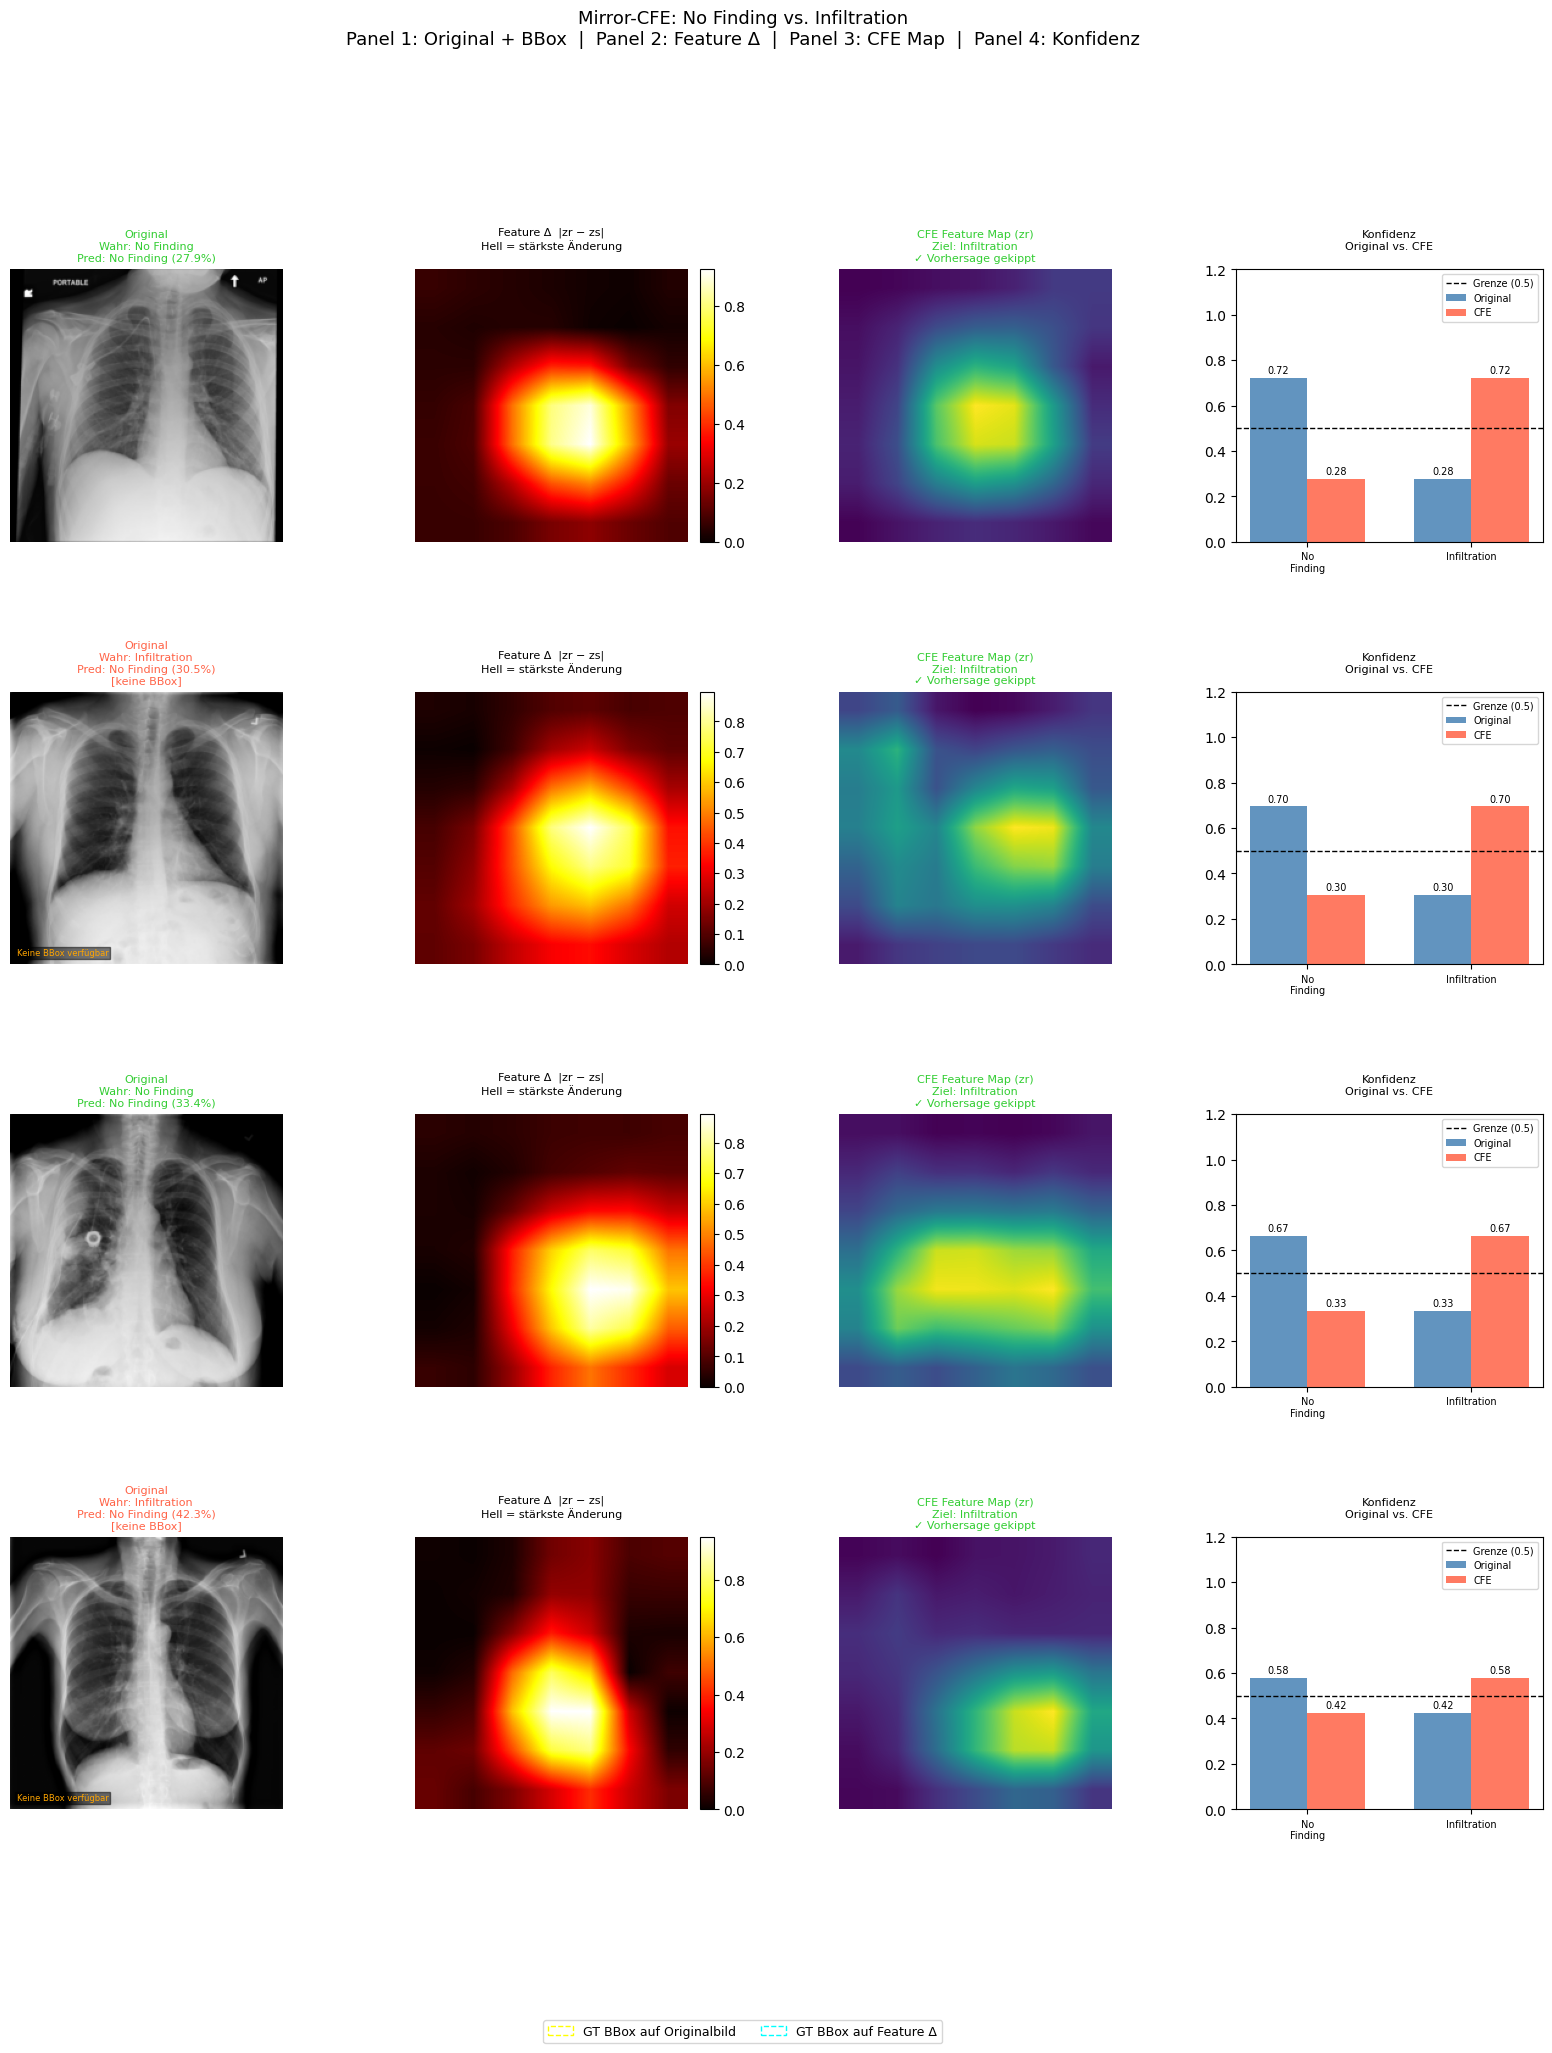

Gespeichert → /kaggle/working/mirror_cfe_bbox.png


In [11]:
visualise_mirror_cfe_with_bbox(
    model         = model,
    images        = sample_images,
    labels        = sample_labels,
    fnames        = sample_fnames,
    mirror_fv     = mirror_fv,
    cfe_labels    = cfe_labels,
    source_labels = source_labels,
    orig_probs    = orig_probs,
    bbox_lookup   = bbox_lookup,
    n_samples     = 4,
    save_path     = '/kaggle/working/mirror_cfe_bbox.png'
)

Infiltration-Bilder mit BBox im Test-Set: 11


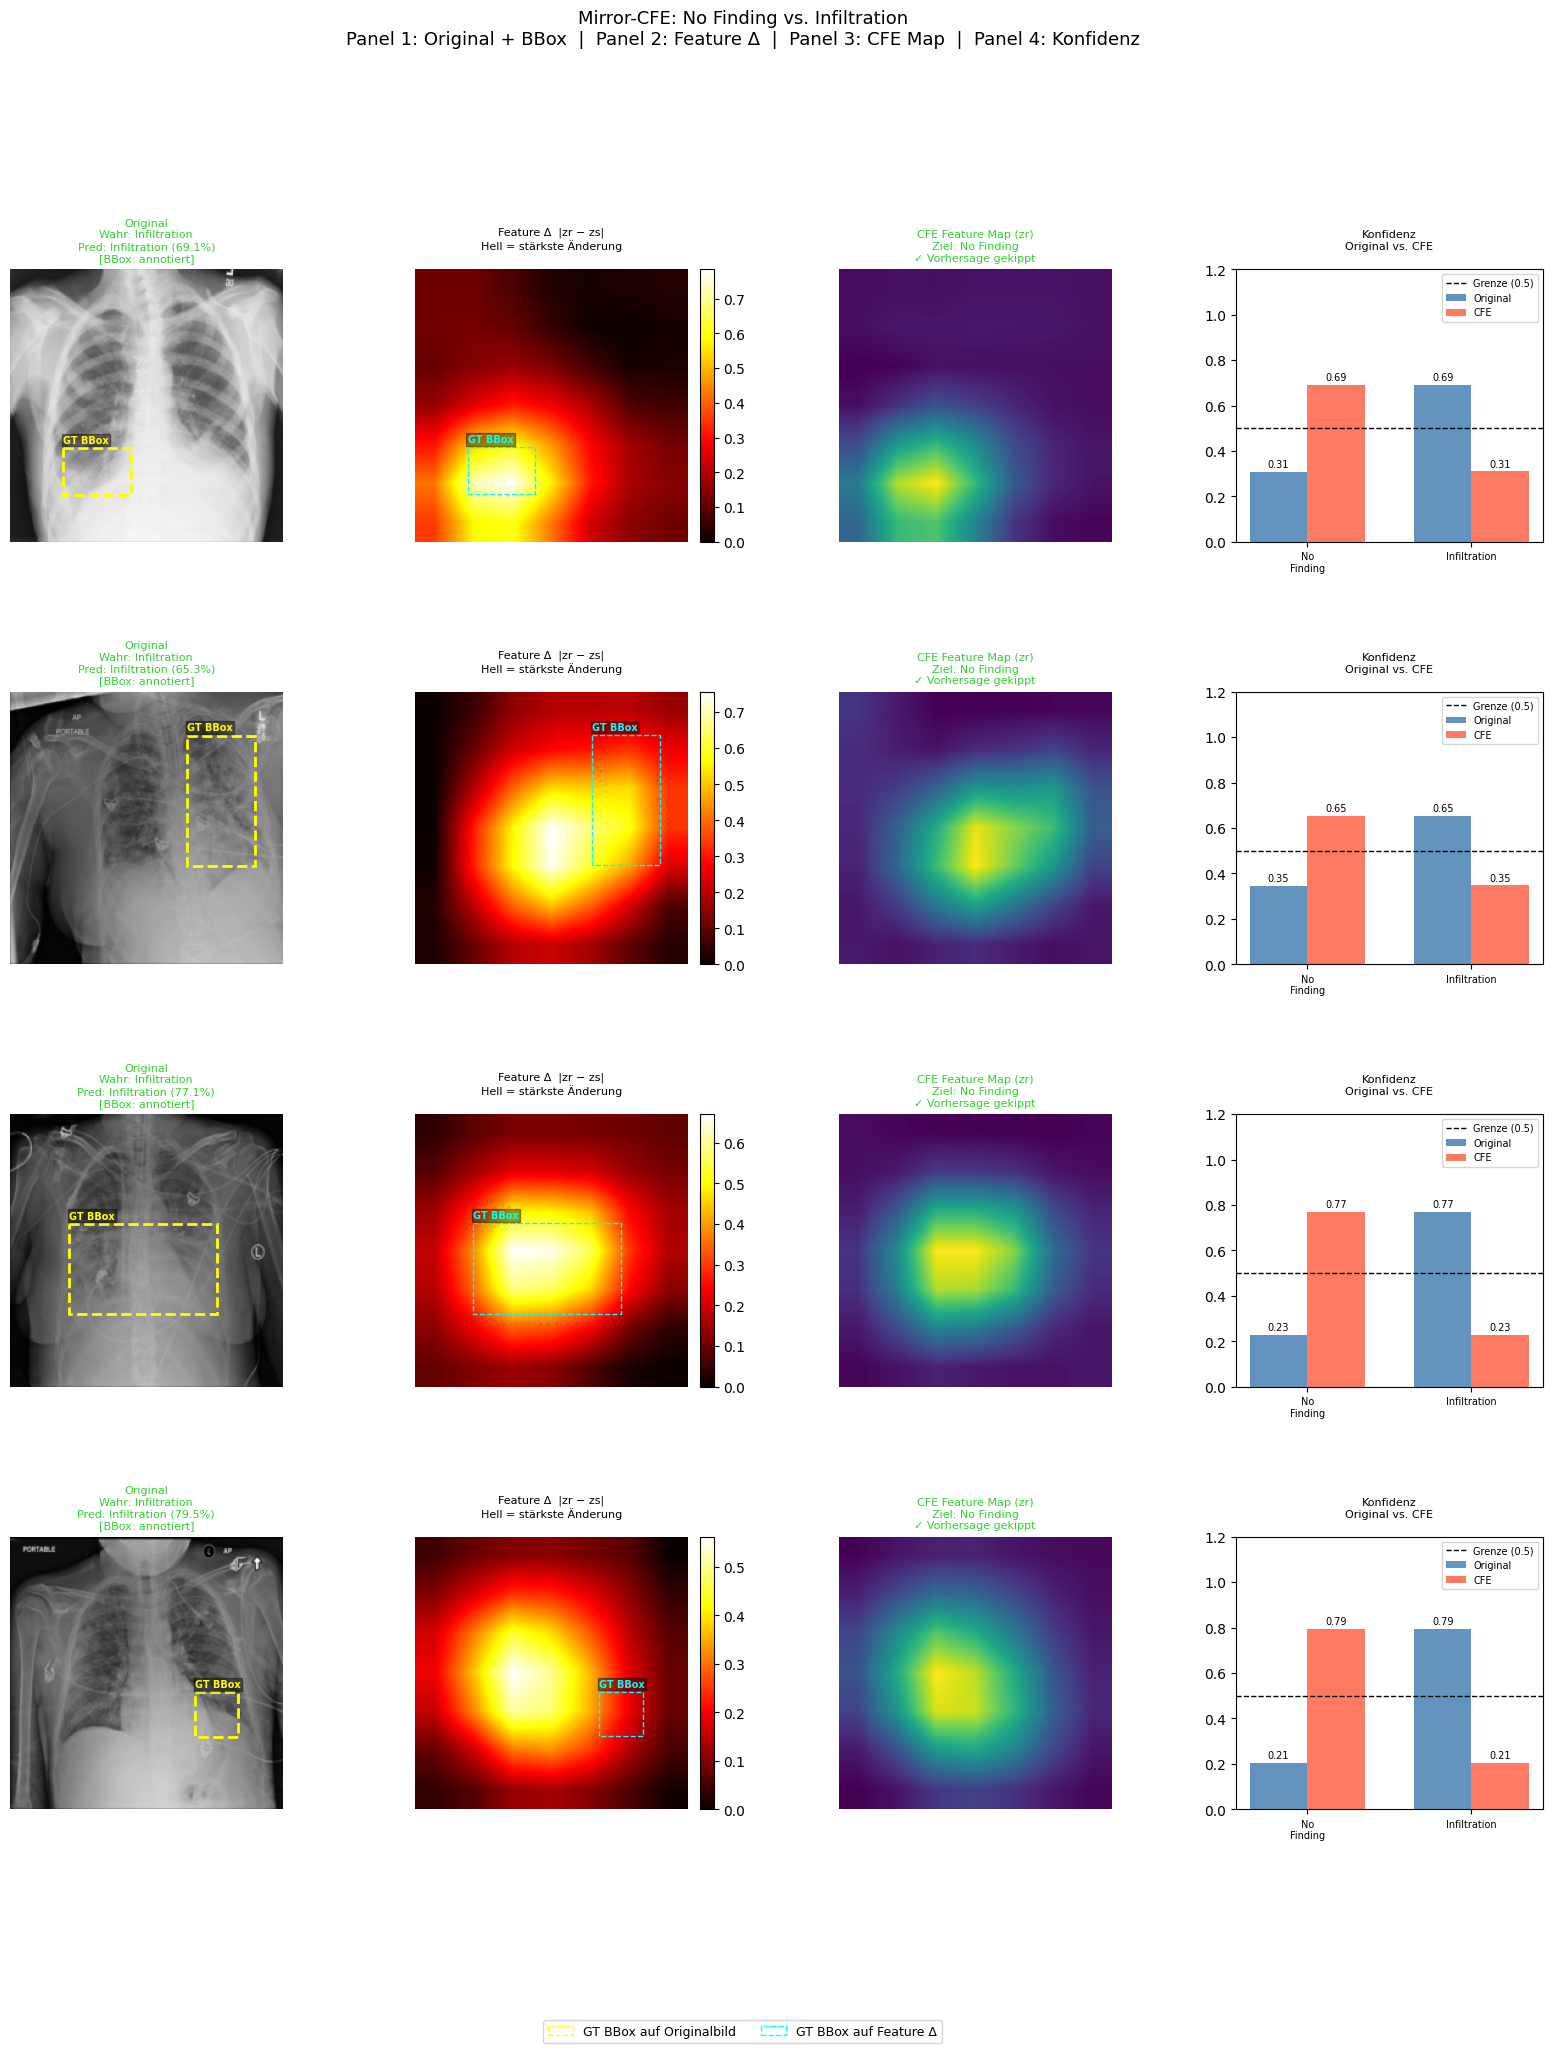

Gespeichert → /kaggle/working/mirror_cfe_infiltration_bbox.png


In [12]:
# Test-Dataframe auf Bilder mit BBox einschränken
bbox_image_names = set(bbox_lookup.keys())
test_with_bbox = test_df[
    (test_df['binary_label'] == 1) &
    (test_df['Image Index'].isin(bbox_image_names))
].reset_index(drop=True)

print(f'Infiltration-Bilder mit BBox im Test-Set: {len(test_with_bbox)}')

if len(test_with_bbox) == 0:
    print('⚠ Keine Bilder mit BBox im Test-Set gefunden.')
    print('  Tipp: BBox-Bilder könnten im Train-Split gelandet sein.')
    print('  Für Visualisierungszwecke alle BBox-Bilder aus dem Gesamt-Datensatz verwenden:')
    test_with_bbox_all = all_xray_df[
        (all_xray_df['binary_label'] == 1) &
        (all_xray_df['Image Index'].isin(bbox_image_names))
    ].reset_index(drop=True)
    print(f'  Gesamt verfügbar: {len(test_with_bbox_all)}')
else:
    bbox_dataset = XRayDataset(test_with_bbox, transform=eval_transforms)
    bbox_loader  = DataLoader(bbox_dataset, batch_size=8,
                              shuffle=True, num_workers=2, pin_memory=False)

    bbox_images, bbox_labels, bbox_fnames = next(iter(bbox_loader))

    mirror_fv_bbox, cfe_lbl_bbox, src_lbl_bbox, orig_bbox = compute_mirror_cfe(
        model, bbox_images, DEVICE, num_iterations=20
    )

    visualise_mirror_cfe_with_bbox(
        model         = model,
        images        = bbox_images,
        labels        = bbox_labels,
        fnames        = bbox_fnames,
        mirror_fv     = mirror_fv_bbox,
        cfe_labels    = cfe_lbl_bbox,
        source_labels = src_lbl_bbox,
        orig_probs    = orig_bbox,
        bbox_lookup   = bbox_lookup,
        n_samples     = 4,
        save_path     = '/kaggle/working/mirror_cfe_infiltration_bbox.png'
    )

In [13]:
n_batches    = 10
total_flip   = 0
total_images = 0

for batch_images, batch_labels, batch_fnames in tqdm(
        list(test_loader)[:n_batches], desc='CFE Evaluation'):

    m_fv, c_lbls, s_lbls, o_probs = compute_mirror_cfe(
        model, batch_images, DEVICE, num_iterations=20
    )
    cfe_p = predict_from_features(model, m_fv).cpu()
    preds = (cfe_p >= 0.5).long()

    total_flip   += (preds == c_lbls.cpu()).sum().item()
    total_images += len(batch_labels)

validity = total_flip / total_images
print(f'\nFlip Rate (Validity): {total_flip}/{total_images} = {validity:.2%}')

CFE Evaluation: 100%|██████████| 10/10 [00:04<00:00,  2.18it/s]


Flip Rate (Validity): 160/160 = 100.00%
